# Panel Models — Simulation Companion

Companion to the slide deck **6 Panel Models** (DiD, Synthetic Control, Synthetic
DiD). Everything is simulated with `panelib` from the
[statanomics](https://github.com/shoepaladin/statanomics) repo, so we always know
the true ATT and can measure **bias** and **confidence-interval coverage**.

All four estimators — **DiD**, **SC-ADH**, **SC-DI**, **SDID** — share the *same*
conformal (time-block permutation) inference, so the comparison is
apples-to-apples. We also run the classical alternative — a TWFE DiD with
**cluster-robust SEs** — to show where each style of inference belongs.

In [1]:
# panelib is the canonical panel library in the statanomics repo. Import it from
# a sibling clone, shallow-cloning it next to this repo if it isn't already there.
import os, sys, io, subprocess, warnings
from contextlib import redirect_stdout
warnings.filterwarnings("ignore")


def _ensure_panelib():
    here = os.getcwd()
    cands = [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here)),
             os.path.expanduser("~")]
    for base in cands:
        p = os.path.join(base, "statanomics", "workingcode", "panelmodels")
        if os.path.exists(os.path.join(p, "panelib.py")):
            return p
    dest = os.path.join(os.path.dirname(here), "statanomics")
    if not os.path.exists(dest):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/shoepaladin/statanomics.git", dest],
                       check=True)
    return os.path.join(dest, "workingcode", "panelmodels")

sys.path.insert(0, _ensure_panelib())
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from panelib import did, sc, sdid, dgp

DD = {"treatment": "treated", "date": "time", "post": "post",
      "unitid": "unit_id", "outcome": "y"}
PARAMS = dict(T_pre=20, T_post=2, N_control=100, noise_sd=0.1,
              att_pct=0.05, rho=0.8)
CONF_GRID = np.arange(-9, 9, 0.025)          # shared conformal grid
EST_COL = {"DiD": "#b91c1c", "SC-ADH": "#0e7490",
           "SC-DI": "#d97706", "SDID": "#6d28d9"}
print("panelib loaded from", _ensure_panelib())

panelib loaded from /home/user/statanomics/workingcode/panelmodels


## The data-generating process

`dgp.simulate_panel` builds a balanced panel: one treated unit and
`N_control` controls, an AR(1) **common** time trend ($\rho$), unit fixed
effects, and noise. `sigma_lambda` controls **unit-specific** linear trends:

* `sigma_lambda = 0` → parallel trends **hold**,
* `sigma_lambda = 1` → parallel trends are **violated** (each unit drifts).

The treatment effect is added to the treated unit's post-period, so the true ATT
is known exactly.

In [2]:
df_par, att_par = dgp.simulate_panel(seed=1, sigma_lambda=0.0, **PARAMS)
df_vio, att_vio = dgp.simulate_panel(seed=1, sigma_lambda=1.0, **PARAMS)
print(f"Scenario 1 (parallel trends)  true ATT = {att_par:.4f}")
print(f"Scenario 2 (violated)         true ATT = {att_vio:.4f}")
tid = df_par.loc[df_par.treated == 1, "unit_id"].iloc[0]
print("treated unit:", tid, "| units:", df_par.unit_id.nunique(),
      "| periods:", df_par.time.nunique())
df_par.head()

Scenario 1 (parallel trends)  true ATT = 0.1072
Scenario 2 (violated)         true ATT = 0.0423
treated unit: u100 | units: 101 | periods: 22


,unit_id,time,treated,post,y
0,u000,0,0,0,0.724051
1,u000,1,0,0,1.243234
2,u000,2,0,0,1.277310
3,u000,3,0,0,1.780360
4,u000,4,0,0,2.038915


## Fit all four estimators, with shared conformal inference

For each model we pull out the treated unit's **observed** trajectory, the
model's predicted **counterfactual**, the estimated **ATT**, and a conformal
**standard error** (so every 95% band is $\hat Y_{cf}\pm1.96\,\mathrm{SE}$).

In [3]:
def fit_all(df, grid=CONF_GRID):
    """Return {model: dict(t, obs, cf, att, se)} for one panel."""
    tid = df.loc[df.treated == 1, "unit_id"].iloc[0]
    out = {}
    with redirect_stdout(io.StringIO()):          # silence panelib prints
        # DiD (TWFE) + conformal inference
        rd = did.twfe(data=df, data_dict=DD)
        infd = did.conformal_inference(data=df, data_dict=DD, theta_grid=grid)
        c = rd["twfe_c"]; rows = c[c.unit_id == tid].sort_values("time")
        out["DiD"] = dict(t=rows.time.to_numpy(), obs=rows.y.to_numpy(),
                          cf=rows.y_hat_counterfactual.to_numpy(),
                          att=infd["real_att"], se=infd["se"])
        # Synthetic control: ADH (simplex) and DI (elastic net)
        for nm, lab in [("adh", "SC-ADH"), ("di", "SC-DI")]:
            r = sc.sc_model(model_name=nm, data=df, data_dict=DD,
                            inference={"alpha": 0.05, "theta_grid": grid})
            pe, rr = r["predict_est"], r["results_df"]
            se = (float(rr.ci_upper.values[0]) - float(rr.ci_lower.values[0])) / (2 * 1.96)
            out[lab] = dict(t=pe.index.to_numpy(), obs=pe[tid].to_numpy(),
                            cf=pe[f"{tid}_est"].to_numpy(),
                            att=float(rr.atet.values[0]), se=se)
        # Synthetic DiD
        rs = sdid.twfe_sdid(data=df, data_dict=DD)
        infs = sdid.conformal_inference(data=df, data_dict=DD, theta_grid=grid)
        cf = rs["counterfactual"]; rr = cf[cf.treated == 1].sort_values("time")
        out["SDID"] = dict(t=rr.time.to_numpy(), obs=rr.y_obs.to_numpy(),
                           cf=rr.y_c.to_numpy(), att=infs["real_att"],
                           se=infs["se"])
    return out


def summary(fit, true_att):
    rows = []
    for m, d in fit.items():
        lo, hi = d["att"] - 1.96 * d["se"], d["att"] + 1.96 * d["se"]
        rows.append(dict(model=m, est_ATT=round(d["att"], 3),
                         true_ATT=round(true_att, 3),
                         bias=round(d["att"] - true_att, 3),
                         ci=f"[{lo:.2f}, {hi:.2f}]",
                         covers=lo <= true_att <= hi))
    return pd.DataFrame(rows).set_index("model")


fit_par = fit_all(df_par)
print("Scenario 1 — parallel trends hold")
summary(fit_par, att_par)

Scenario 1 — parallel trends hold


,est_ATT,true_ATT,bias,ci,covers
model,,,,,
DiD,0.027,0.107,-0.080,"[-0.07, 0.13]",True
SC-ADH,0.040,0.107,-0.067,"[-0.02, 0.10]",False
SC-DI,0.401,0.107,0.294,"[-0.40, 1.20]",True
SDID,0.014,0.107,-0.094,"[-0.05, 0.08]",False


In [4]:
fit_vio = fit_all(df_vio)
print("Scenario 2 — parallel trends violated")
summary(fit_vio, att_vio)

Scenario 2 — parallel trends violated


,est_ATT,true_ATT,bias,ci,covers
model,,,,,
DiD,-0.737,0.042,-0.780,"[-1.27, -0.20]",False
SC-ADH,-0.118,0.042,-0.160,"[-0.21, -0.03]",False
SC-DI,-0.088,0.042,-0.131,"[-0.25, 0.07]",True
SDID,-0.015,0.042,-0.058,"[-0.13, 0.10]",True


## Trajectories: observed vs. counterfactual

Same treated unit in every panel (solid), each model's counterfactual (dashed)
with its 95% conformal band in the post-period. SC-DI is omitted from the plot —
on this DGP its elastic net shrinks the donor weights to ~0, giving an
intercept-only (flat) counterfactual that is unbiased *on average* (kept in the
Monte-Carlo below) but reads as broken on a single draw.

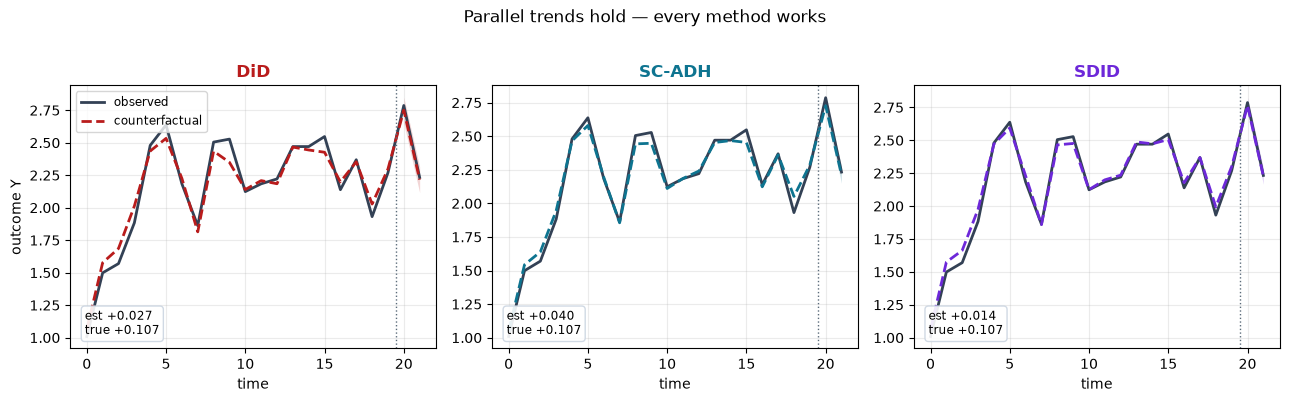

In [5]:
def plot_trajectories(fit, true_att, t0, title):
    models = ["DiD", "SC-ADH", "SDID"]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharex=True)
    for ax, m in zip(axes, models):
        d = fit[m]; col = EST_COL[m]
        t, obs, cf, se = d["t"], d["obs"], d["cf"], d["se"]
        post = t >= t0
        ax.plot(t, obs, color="#334155", lw=2, label="observed")
        ax.plot(t, cf, "--", color=col, lw=2, label="counterfactual")
        ax.fill_between(t[post], cf[post] - 1.96 * se, cf[post] + 1.96 * se,
                        color=col, alpha=.18, lw=0)
        ax.axvline(t0 - .5, color="#5b6b7a", ls=":", lw=1)
        ax.set_title(m, color=col, fontweight="bold"); ax.set_xlabel("time")
        ax.grid(alpha=.25)
        ax.text(.04, .04, f"est {d['att']:+.3f}\ntrue {true_att:+.3f}",
                transform=ax.transAxes, fontsize=8.5, va="bottom",
                bbox=dict(boxstyle="round", fc="white", ec="#cbd5e1", alpha=.9))
    axes[0].set_ylabel("outcome Y"); axes[0].legend(fontsize=8.5, loc="upper left")
    fig.suptitle(title, y=1.02); fig.tight_layout(); plt.show()


plot_trajectories(fit_par, att_par, PARAMS["T_pre"],
                  "Parallel trends hold — every method works")

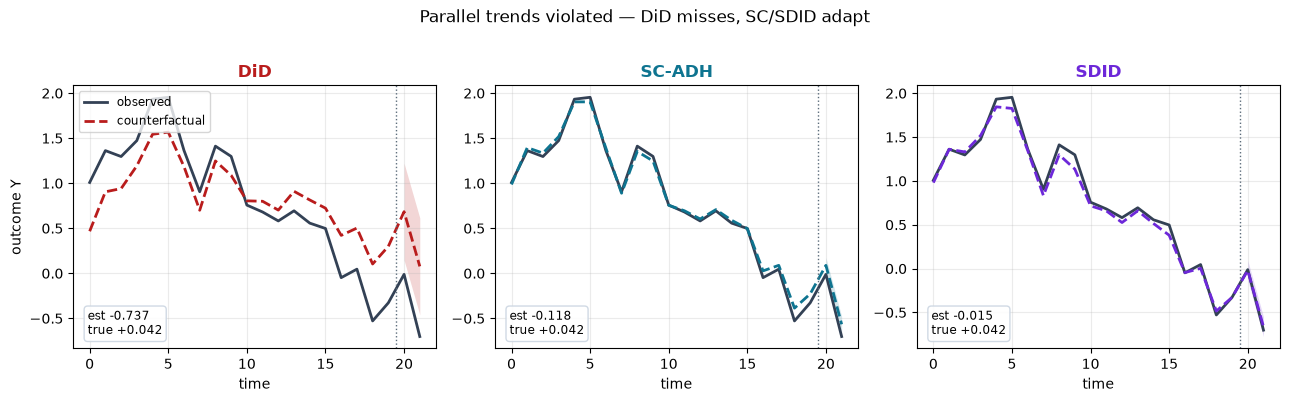

In [6]:
plot_trajectories(fit_vio, att_vio, PARAMS["T_pre"],
                  "Parallel trends violated — DiD misses, SC/SDID adapt")

## Classical inference check: clustered SEs
Conformal inference is the right tool *here* because there is a single treated
unit. With **many** treated units the workhorse is the TWFE regression with
**cluster-robust SEs at the unit level** — clustered because outcomes are
serially correlated within units, and ignoring that badly understates DiD
standard errors (Bertrand, Duflo & Mullainathan 2004).

We run it on the same panels for comparison. The two point estimates coincide
(it is the same TWFE regression) — the difference is the interval, and the
caveat *is* the point: with **one treated cluster**, a cluster-robust SE is
estimated from a single cluster's residuals, so it is **erratic** rather than
simply narrow — too tight in the parallel-trends draw below, too wide in the
violated one. Neither behavior is trustworthy; conformal inference is built
for exactly this one-unit case and behaves consistently across both.
And no standard error fixes the violated scenario: the *point estimate* is
exactly as biased as conformal DiD there, because the problem is
identification, not inference.

In [7]:
import statsmodels.formula.api as smf


def twfe_clustered(df):
    m = smf.ols("y ~ C(unit_id) + C(time) + treated:post", data=df).fit(
        cov_type="cluster", cov_kwds={"groups": df["unit_id"]})
    return m.params["treated:post"], m.bse["treated:post"]


for label, df, att, fit in [("parallel", df_par, att_par, fit_par),
                            ("violated", df_vio, att_vio, fit_vio)]:
    est, se = twfe_clustered(df)
    d = fit["DiD"]
    print(f"{label:9s}: clustered TWFE tau = {est:+.3f} ± {1.96 * se:.3f}   "
          f"conformal DiD tau = {d['att']:+.3f} ± {1.96 * d['se']:.3f}   "
          f"(true {att:+.3f})")

parallel : clustered TWFE tau = +0.027 ± 0.015   conformal DiD tau = +0.027 ± 0.100   (true +0.107)
violated : clustered TWFE tau = -0.737 ± 2.157   conformal DiD tau = -0.737 ± 0.538   (true +0.042)


## Monte-Carlo: bias and coverage across many simulations

We repeat the fit over many seeds and both scenarios, recording the error
($\hat\tau-\tau$) and whether the 95% interval covers the truth.

One metric subtlety: under the violation each seed's treated unit draws its
**own** trend, so DiD's error is enormous but *sign-random* across seeds — the
mean signed bias averages toward zero and hides the problem. We therefore
report the **mean absolute error** as well; that is what the deck's figure
shows.

The full run (200 seeds × 2 scenarios × 4 models, each with conformal inference)
takes a few hours, so it is guarded behind `RUN_FULL_MC`. By default we **load
the committed results** (`panel_mc_results.csv`, produced by `panel_mc.py`); set
`RUN_FULL_MC = True` to regenerate from scratch.

In [8]:
RUN_FULL_MC = False
N_SEEDS = 200
SCENARIOS = {"parallel": 0.0, "violated": 1.0}
CSV = "panel_mc_results.csv"


def run_mc(n_seeds=N_SEEDS):
    rows = []
    for scen, sig in SCENARIOS.items():
        for seed in range(n_seeds):
            df, true_att = dgp.simulate_panel(seed=seed, sigma_lambda=sig, **PARAMS)
            for m, d in fit_all(df).items():
                lo, hi = d["att"] - 1.96 * d["se"], d["att"] + 1.96 * d["se"]
                rows.append(dict(scenario=scen, seed=seed, model=m,
                                 true_att=true_att, att=d["att"],
                                 bias=d["att"] - true_att,
                                 covered=int(lo <= true_att <= hi)))
    return pd.DataFrame(rows)


if RUN_FULL_MC:
    mc = run_mc(); mc.to_csv(CSV, index=False)
else:
    mc = pd.read_csv(CSV)
print(len(mc), "rows |", mc.scenario.unique(), "|", sorted(mc.model.unique()))

1600 rows | <StringArray>
['parallel', 'violated']
Length: 2, dtype: str | ['DiD', 'SC-ADH', 'SC-DI', 'SDID']


In [9]:
order = ["DiD", "SC-ADH", "SC-DI", "SDID"]
bias_tbl = (mc.groupby(["model", "scenario"])["bias"].mean()
            .unstack("scenario").reindex(order).round(3))
abs_tbl = (mc.groupby(["model", "scenario"])["bias"].apply(lambda s: s.abs().mean())
           .unstack("scenario").reindex(order).round(3))
cov_tbl = (mc.groupby(["model", "scenario"])["covered"].mean()
           .unstack("scenario").reindex(order).round(3))
print("Mean signed bias (est - true ATT):"); display(bias_tbl)
print("\nMean |est - true ATT| — the honest error metric here:"); display(abs_tbl)
print("\n95% CI coverage:"); display(cov_tbl)

Mean signed bias (est - true ATT):


scenario,parallel,violated
model,,
DiD,0.001,-0.311
SC-ADH,0.003,0.160
SC-DI,0.007,-0.001
SDID,0.003,-0.021



Mean |est - true ATT| — the honest error metric here:


scenario,parallel,violated
model,,
DiD,0.065,8.486
SC-ADH,0.072,0.299
SC-DI,0.438,0.249
SDID,0.068,0.157



95% CI coverage:


scenario,parallel,violated
model,,
DiD,0.96,0.020
SC-ADH,0.85,0.735
SC-DI,0.80,0.525
SDID,0.81,0.840


## Takeaways

* **Under parallel trends, everything works** — all four estimators are roughly
  unbiased and their intervals cover near the nominal rate.
* **Under a trend violation, DiD breaks**: its average miss is ~8.5 (vs ~0.2 for
  SC/SDID) and its confidence interval almost never covers the truth — it stays
  tight while pointing the wrong way. (Its *signed* bias averages out across
  simulations only because the rogue trend is as often up as down.)
* **SC and SDID adapt** because they fit the treated unit's own trajectory. SDID
  tends to combine low bias with the coverage closest to nominal — the payoff of
  hedging DiD's assumption with SC-style weights.
* **Coverage fine print**: even under parallel trends, the conformal intervals
  for SC/SDID cover 80–85%, not 95% — with only 2 post-periods the permutation
  p-value is coarse, and the ±1.96·SE band is a normal approximation to the
  inverted test. More post-periods sharpen both.
* **Pick inference to match the design**: one treated unit → conformal /
  permutation; many treated units → cluster-robust SEs (with wild bootstrap
  when clusters are few). No standard error rescues a broken identification.
* **Match the method to the counterfactual you can defend**, and let the event
  study and pre-period fit tell you which assumption is doing the work.